In [9]:
import os
import re
import glob
import sys
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path

# ─── 0) Ensure we can import ODG and force CPU-only ──────────────────────────
parentdir = os.path.dirname(os.getcwd())
sys.path.insert(0, parentdir)

import OptimizedDataGenerator4 as ODG
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    Input, Reshape, Conv3D, MaxPooling3D,
    Flatten, Dense, Dropout, Concatenate
)
import matplotlib.pyplot as plt
from pathlib import Path
from tensorflow.keras.models import Model

In [ ]:
BASE_DIR       = Path("/home/youeric/PixelML/smart_pixels_ml/filtering_models/filtering_records2048test")
train_dir      = BASE_DIR / "tfrecords_train"
val_dir = BASE_DIR / "tfrecords_validation"


train_gen = ODG.OptimizedDataGenerator(
        load_records=True,
        tf_records_dir=str(train_dir),
        x_feature_description=['cluster', 'z_global'],
        batch_size=2048
    )
val_gen = ODG.OptimizedDataGenerator(
        load_records=True,
        tf_records_dir=str(val_dir),
        x_feature_description=['cluster', 'z_global'],
        batch_size=2048
    )


def build_convolutional_model2(input_shape=(13, 21, 20), num_classes=2):
    """
    - No Permute: assumes your loader emits (H, W, T)
    - Adds channel axis via Reshape
    - Applies a Dense(16) to z_global before concat
    - Inserts Dense(32) before the final output
    - Only one sigmoid/softmax activation at the end
    """
    vol_input = Input(shape=input_shape, name='cluster')
    z_input   = Input(shape=(1,), name='z_global')

    x = Reshape(target_shape=(*input_shape, 1), name='add_channel')(vol_input)
    x = Conv3D(32, (3,3,3), padding='same', activation='relu', name='conv3d_1')(x)
    x = MaxPooling3D((2,2,2), name='pool3d_1')(x)
    x = Conv3D(64, (3,3,3), padding='same', activation='relu', name='conv3d_2')(x)
    x = MaxPooling3D((2,2,2), name='pool3d_2')(x)
    x = Flatten(name='flatten')(x)

    z_dense = Dense(16, activation='relu', name='z_dense')(z_input)
    x = Concatenate(name='concat')([x, z_dense])

    x = Dense(64, activation='relu', name='dense_1')(x)
    x = Dropout(0.5, name='dropout')(x)
    x = Dense(32, activation='relu', name='dense_small')(x)

    if num_classes == 2:
        output = Dense(1, activation='sigmoid', name='output')(x)
        loss = 'binary_crossentropy'
    else:
        output = Dense(num_classes, activation='softmax', name='output')(x)
        loss = 'categorical_crossentropy'

    model = tf.keras.Model([vol_input, z_input], output, name='Conv3D_no_permute')
    model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])
    return model

Model: "Conv3D_no_permute"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cluster             │ (None, 13, 21,    │          0 │ -                 │
│ (InputLayer)        │ 20)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_channel         │ (None, 13, 21,    │          0 │ cluster[0][0]     │
│ (Reshape)           │ 20, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 13, 21,    │        896 │ add_channel[0][0] │
│                     │ 20, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3d_1            │ (None, 6, 10, 10, │          0 │ conv3d_1[0][0]    │
│ (MaxPooling3D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 6, 10, 10, │     55,360 │ pool3d_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3d_2            │ (None, 3, 5, 5,   │          0 │ conv3d_2[0][0]    │
│ (MaxPooling3D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_global            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4800)      │          0 │ pool3d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_dense (Dense)     │ (None, 16)        │         32 │ z_global[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 4816)      │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ z_dense[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │    308,288 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_small (Dense) │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dense_small[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 366,689 (1.40 MB)

 Trainable params: 366,689 (1.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step - accuracy: 0.5507 - loss: 1.1133 - val_accuracy: 0.4230 - val_loss: 0.6955
Epoch 2/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.4525 - loss: 0.6994 - val_accuracy: 0.5054 - val_loss: 0.6930
Epoch 3/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step - accuracy: 0.5115 - loss: 0.6926 - val_accuracy: 0.5361 - val_loss: 0.6906
Epoch 4/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.4537 - loss: 0.6977 - val_accuracy: 0.5708 - val_loss: 0.6788
Epoch 5/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.4814 - loss: 0.6940 - val_accuracy: 0.6235 - val_loss: 0.6834
Epoch 6/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - accuracy: 0.5879 - loss: 0.6821 - val_accuracy: 0.6140 - val_loss: 0.6733
Epoch 7/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - accuracy: 0.6155 - loss: 0.6723 - val_accuracy: 0.6122 - val_loss: 0.6814
Epoch 8/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step - accuracy: 0.5753 - loss: 0.6789 - val_acc

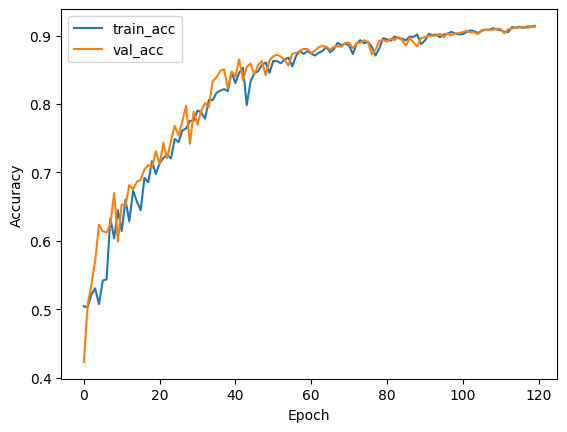

In [11]:
# ─── 0) Define your hyper-params / config ──────────────────────────────────
config = {
    "kind": "polynomial_decay",
    "initial_lr": 1e-3,
    "end_lr":      1e-4,
    "power":       1.0,
}
epochs = 120

# ─── 1) Build your model (assumes build_convolutional_model2 is already in scope) ───
model = build_convolutional_model2(input_shape=(13,21,20), num_classes=2)

# ─── 2) Choose your optimizer (with polynomial decay) ────────────────────────
steps_per_epoch = len(train_gen)  # number of batches in an epoch

if config["kind"] == "polynomial_decay":
    lr_schedule = tf.keras.optimizers.schedules.PolynomialDecay(
        initial_learning_rate = config["initial_lr"],
        decay_steps           = steps_per_epoch * epochs,
        end_learning_rate     = config.get("end_lr", 1e-5),
        power                 = config.get("power", 1.0)
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
else:
    # fallback to a plain Adam
    optimizer = tf.keras.optimizers.Adam(learning_rate=config["initial_lr"])

# ─── 3) Compile ─────────────────────────────────────────────────────────────
model.compile(
    optimizer = optimizer,
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

model.summary()

# ─── 4) Callbacks (early stopping with patience=40) ─────────────────────────
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor               = 'val_loss',
        patience              = 40,
        restore_best_weights  = True
    )
]

# ─── 5) Train for 200 epochs ────────────────────────────────────────────────
history = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = epochs,
    callbacks       = callbacks
)

# ─── 6) Plot ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],    label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

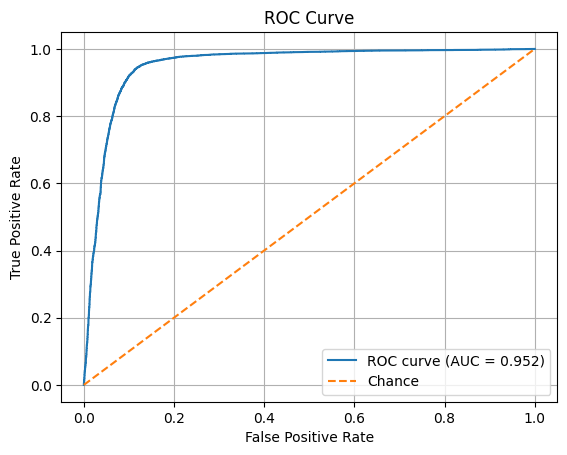

In [12]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1) Get predicted probabilities for the positive class on the val set
#    model.predict(val_gen) will return an array of shape (N,1)
y_score = model.predict(val_gen, verbose=0).ravel()

# 2) Gather the true labels by iterating over the Sequence
y_true = np.concatenate([y for _, y in (val_gen[i] for i in range(len(val_gen)))])

# 3) Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# 4) Plot
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], '--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

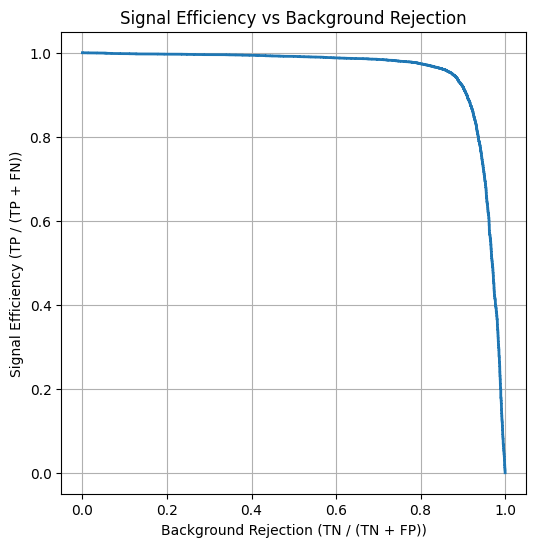

: 

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve
import matplotlib.pyplot as plt

# 1) Get your scores & labels
y_score = model.predict(val_gen, verbose=0).ravel()
y_true  = np.concatenate([y for _, y in (val_gen[i] for i in range(len(val_gen)))])

# 2) Use roc_curve just to get a sensible set of thresholds
_, _, thresholds = roc_curve(y_true, y_score)

# 3) Loop over each threshold, compute your metrics
signal_efficiencies   = []
background_rejections = []

for thr in thresholds:
    y_pred = (y_score >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # your definitions:
    sig_eff = tp / (tp + fn)    # TP/(TP+FN)
    bkg_rej = tn / (tn + fp)    # TN/(TN+FP)

    signal_efficiencies.append(sig_eff)
    background_rejections.append(bkg_rej)

# 4) Plot “like‐ROC” curve (Signal Eff vs. Bkg Rej)
plt.figure(figsize=(6,6))
plt.plot(background_rejections, signal_efficiencies, lw=2)
plt.xlabel('Background Rejection (TN / (TN + FP))')
plt.ylabel('Signal Efficiency (TP / (TP + FN))')
plt.title('Signal Efficiency vs Background Rejection')
plt.grid(True)
plt.show()